In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

In [2]:
def generate_images(N=3000):
    X = np.zeros((N,8,8))
    y = np.zeros((N,1))

    for i in range(N):
        img = np.zeros((8,8))
        if np.random.rand() > 0.5:
            img[:,4] = 1
            y[i] = 0
        else:
            img[4,:] = 1
            y[i] = 1

        img += np.random.normal(0,0.1,(8,8))
        X[i] = img

    return X,y

X,y = generate_images(3000)

In [3]:
idx = np.random.permutation(len(X))
X,y = X[idx],y[idx]

train_end = int(0.7*len(X))
val_end = int(0.85*len(X))

X_train,X_val,X_test = X[:train_end],X[train_end:val_end],X[val_end:]
y_train,y_val,y_test = y[:train_end],y[train_end:val_end],y[val_end:]

def init_cnn():
    params = {}
    params["K1"] = np.random.randn(3,3)*0.1
    params["b1"] = 0.0
    params["W2"] = np.random.randn(9,1)*0.1
    params["b2"] = 0.0
    return params

def conv_forward(X,K,b):
    N,H,W = X.shape
    F = K.shape[0]
    out = np.zeros((N,H-F+1,W-F+1))
    for n in range(N):
        for i in range(H-F+1):
            for j in range(W-F+1):
                region = X[n,i:i+F,j:j+F]
                out[n,i,j] = np.sum(region*K)+b
    return out

In [4]:
def maxpool_forward(X):
    N,H,W = X.shape
    out = np.zeros((N,H//2,W//2))
    for n in range(N):
        for i in range(H//2):
            for j in range(W//2):
                region = X[n,i*2:(i+1)*2,j*2:(j+1)*2]
                out[n,i,j] = np.max(region)
    return out

def cnn_forward(X,params):
    conv = conv_forward(X,params["K1"],params["b1"])
    relu = np.maximum(0,conv)
    pool = maxpool_forward(relu)
    flat = pool.reshape(len(pool),-1)
    Z = flat @ params["W2"] + params["b2"]
    out = 1/(1+np.exp(-Z))
    cache = (X,conv,relu,pool,flat,out)
    return out,cache

In [5]:
def maxpool_backward(dpool,relu):
    N,H,W = relu.shape
    d_relu = np.zeros_like(relu)
    for n in range(N):
        for i in range(H//2):
            for j in range(W//2):
                region = relu[n,i*2:(i+1)*2,j*2:(j+1)*2]
                max_val = np.max(region)
                for x in range(2):
                    for y in range(2):
                        if region[x,y]==max_val:
                            d_relu[n,i*2+x,j*2+y] = dpool[n,i,j]
    return d_relu

def conv_backward(dconv,X,K):
    N,H,W = X.shape
    F = K.shape[0]
    dK = np.zeros_like(K)
    for n in range(N):
        for i in range(H-F+1):
            for j in range(W-F+1):
                region = X[n,i:i+F,j:j+F]
                dK += region*dconv[n,i,j]
    return dK/N


In [8]:
def cnn_backward(y,cache,params):
    X,conv,relu,pool,flat,out = cache
    m = len(X)
    dout = out - y
    dW2 = flat.T @ dout / m
    db2 = np.sum(dout)/m
    dflat = dout @ params["W2"].T
    dpool = dflat.reshape(pool.shape)
    d_relu = maxpool_backward(dpool,relu)
    dconv = d_relu*(conv>0)
    dK = conv_backward(dconv,X,params["K1"])
    grads = {
        "dK1":dK,
        "db1":np.sum(dconv)/m,
        "dW2":dW2,
        "db2":db2
    }
    return grads


In [9]:
def compute_loss(y_hat,y):
    y_hat = np.clip(y_hat,1e-8,1-1e-8)
    return -np.mean(y*np.log(y_hat)+(1-y)*np.log(1-y_hat))

def compute_accuracy(y_hat,y):
    return np.mean((y_hat>=0.5)==y)


SGD Test Accuracy: 0.9422222222222222
MOMENTUM Test Accuracy: 1.0
ADAM Test Accuracy: 1.0


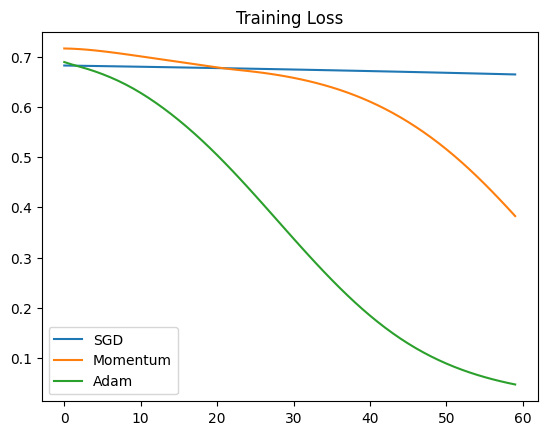

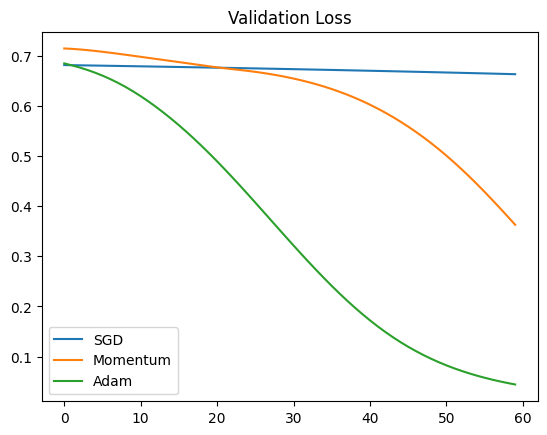

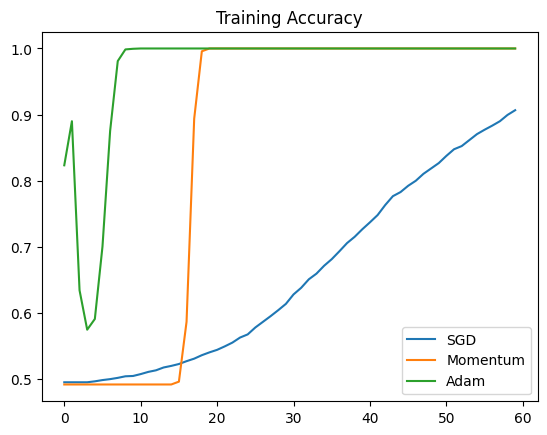

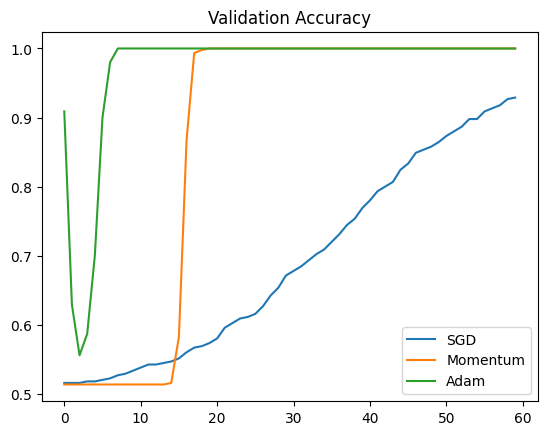

In [10]:
def train_optimizer(opt="sgd",epochs=60,lr=0.01):

    params = init_cnn()
    velocity = {k:np.zeros_like(v) for k,v in params.items()}
    m = {k:np.zeros_like(v) for k,v in params.items()}
    v = {k:np.zeros_like(v) for k,v in params.items()}

    train_loss,val_loss = [],[]
    train_acc,val_acc = [],[]

    for epoch in range(1,epochs+1):

        out,cache = cnn_forward(X_train,params)
        loss = compute_loss(out,y_train)
        acc = compute_accuracy(out,y_train)
        grads = cnn_backward(y_train,cache,params)

        for key in params:
            if opt=="sgd":
                params[key] -= lr*grads["d"+key]

            elif opt=="momentum":
                velocity[key] = 0.9*velocity[key] + lr*grads["d"+key]
                params[key] -= velocity[key]

            elif opt=="adam":
                m[key] = 0.9*m[key] + 0.1*grads["d"+key]
                v[key] = 0.999*v[key] + 0.001*(grads["d"+key]**2)
                m_hat = m[key]/(1-0.9**epoch)
                v_hat = v[key]/(1-0.999**epoch)
                params[key] -= lr*m_hat/(np.sqrt(v_hat)+1e-8)

        val_out,_ = cnn_forward(X_val,params)

        train_loss.append(loss)
        val_loss.append(compute_loss(val_out,y_val))
        train_acc.append(acc)
        val_acc.append(compute_accuracy(val_out,y_val))

    test_out,_ = cnn_forward(X_test,params)
    test_acc = compute_accuracy(test_out,y_test)

    print(opt.upper(),"Test Accuracy:",test_acc)

    return train_loss,val_loss,train_acc,val_acc,test_acc

sgd = train_optimizer("sgd")
momentum = train_optimizer("momentum")
adam = train_optimizer("adam")

plt.figure()
plt.plot(sgd[0],label="SGD")
plt.plot(momentum[0],label="Momentum")
plt.plot(adam[0],label="Adam")
plt.title("Training Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(sgd[1],label="SGD")
plt.plot(momentum[1],label="Momentum")
plt.plot(adam[1],label="Adam")
plt.title("Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(sgd[2],label="SGD")
plt.plot(momentum[2],label="Momentum")
plt.plot(adam[2],label="Adam")
plt.title("Training Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(sgd[3],label="SGD")
plt.plot(momentum[3],label="Momentum")
plt.plot(adam[3],label="Adam")
plt.title("Validation Accuracy")
plt.legend()
plt.show()


In [11]:
param_count = (3*3*1 + 1) + (9*1 + 1)

master = pd.DataFrame({
    "Model":["CNN","CNN","CNN"],
    "Depth":["Conv+Dense"]*3,
    "Activation":["ReLU"]*3,
    "Optimizer":["SGD","Momentum","Adam"],
    "Params":[param_count]*3,
    "Train Acc":[sgd[2][-1],momentum[2][-1],adam[2][-1]],
    "Val Acc":[sgd[3][-1],momentum[3][-1],adam[3][-1]],
    "Test Acc":[sgd[4],momentum[4],adam[4]]
})

master

,Model,Depth,Activation,Optimizer,Params,Train Acc,Val Acc,Test Acc
0,CNN,Conv+Dense,ReLU,SGD,20,0.906667,0.928889,0.942222
1,CNN,Conv+Dense,ReLU,Momentum,20,1.000000,1.000000,1.000000
2,CNN,Conv+Dense,ReLU,Adam,20,1.000000,1.000000,1.000000


Epoch: 0 Loss: 0.7078 Acc: 0.099

Epoch: 20 Loss: 0.692 Acc: 0.5552

Epoch: 40 Loss: 0.6767 Acc: 0.9762

Epoch: 60 Loss: 0.6604 Acc: 0.9995

Epoch: 80 Loss: 0.6419 Acc: 1.0

Epoch: 100 Loss: 0.6202 Acc: 1.0
Validation Acc: 1.0

Test Acc: 1.0